In [1]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt
import seaborn as sns

import lightgbm as lgb

import warnings

warnings.filterwarnings("ignore")


SEED = 1

In [2]:
df_train = pd.read_parquet("train.parquet")
df_test = pd.read_parquet("test.parquet")
sample_submission = pd.read_csv("sample_submission.csv")

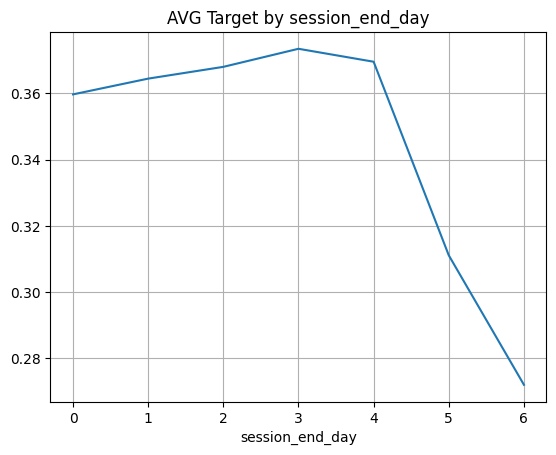

In [3]:
df_train["order_create_day"] = df_train["order_create_time"].dt.dayofweek
df_train["session_end_day"]   = df_train["session_end_time"].dt.dayofweek

df_test["order_create_day"]  = df_test["order_create_time"].dt.dayofweek
df_test["session_end_day"]   = df_test["session_end_time"].dt.dayofweek

df_train.groupby("session_end_day")["target"].mean().plot()
plt.title("AVG Target by session_end_day")
plt.grid()

In [4]:
df_train["minutes_until_end"] = (df_train["session_end_time"] - df_train["order_create_time"]).dt.total_seconds() / 60
df_test["minutes_until_end"] = (df_test["session_end_time"] - df_test["order_create_time"]).dt.total_seconds() / 60

df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=SEED, stratify=df_train["target"])

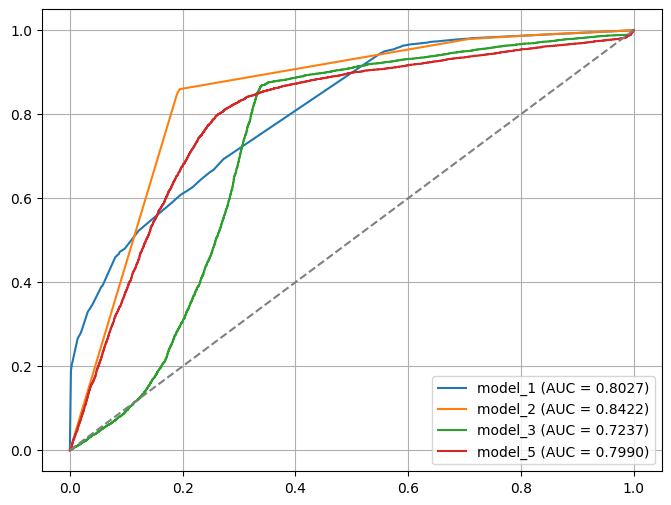

In [5]:
models = [f"model_{i}" for i in [1, 2, 3, 5]]

plt.figure(figsize=(8, 6))

curves = [
    roc_curve(df_val["target"], df_val[score_pred]) for score_pred in models
]

for model, (fpr, tpr, thresholds) in zip(models, curves):
    auc = roc_auc_score(df_train["target"], df_train[model])
    plt.plot(fpr, tpr, label=f"{model} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.legend()
plt.grid()

plt.show()

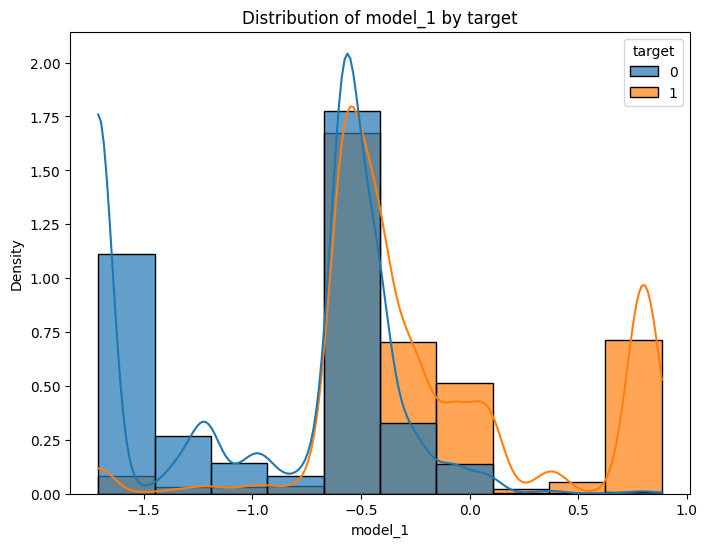

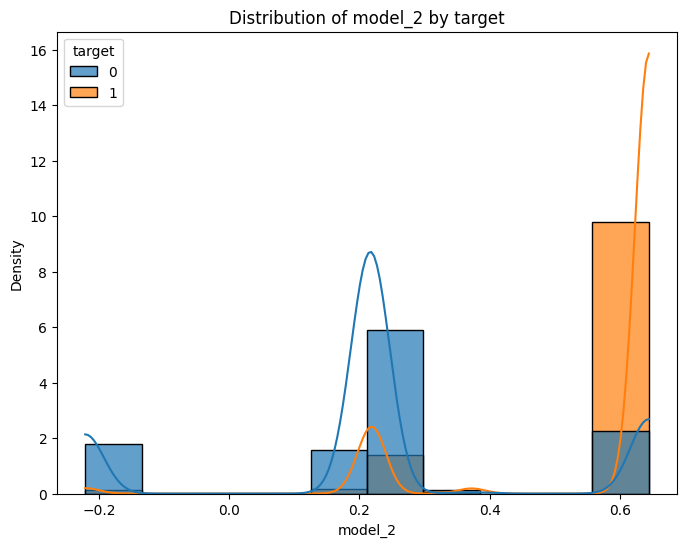

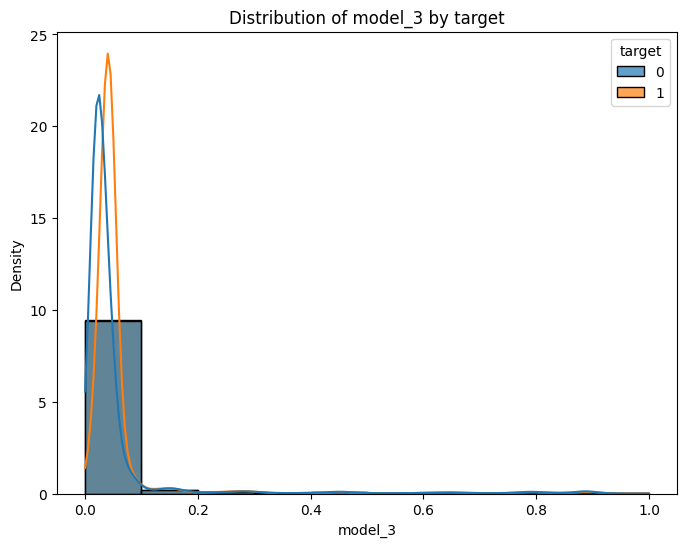

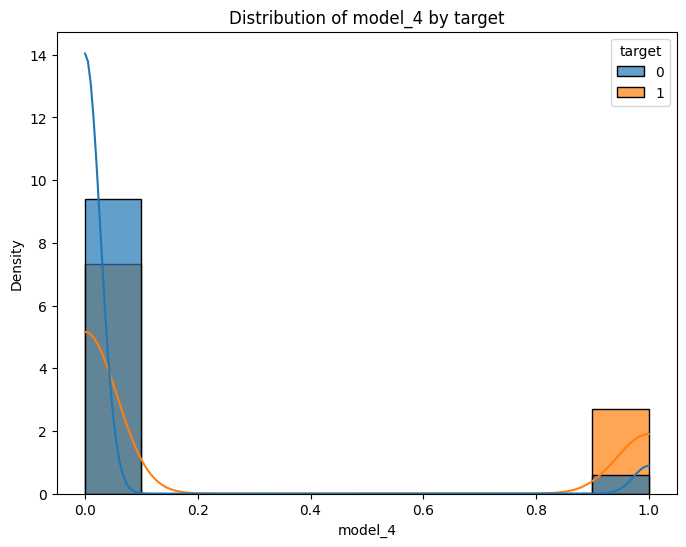

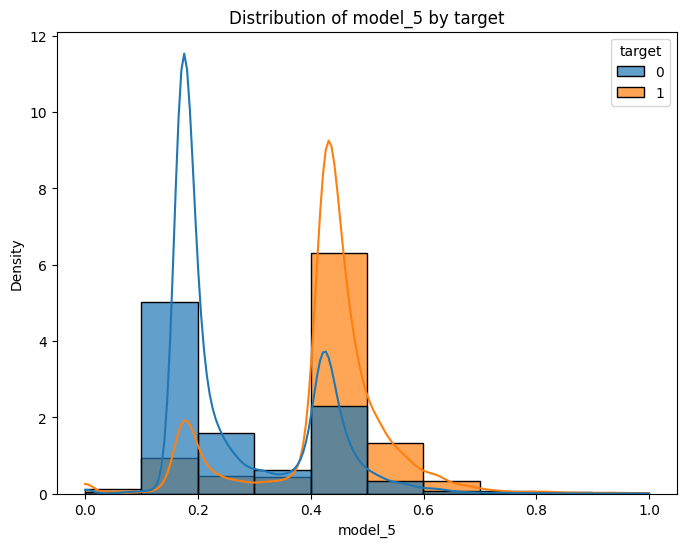

In [6]:
models = [f"model_{i}" for i in [1, 2, 3, 4, 5]]

for model in models:
    plt.figure(figsize=(8, 6))
    sns.histplot(
        df_train,
        x=model,
        hue="target",
        bins=10,
        kde=True,
        stat="density",
        common_norm=False,
        alpha=0.7,
        fill=True,
        edgecolor="black",
    )
    plt.title(f"Distribution of {model} by target")
    plt.show()
    plt.close()

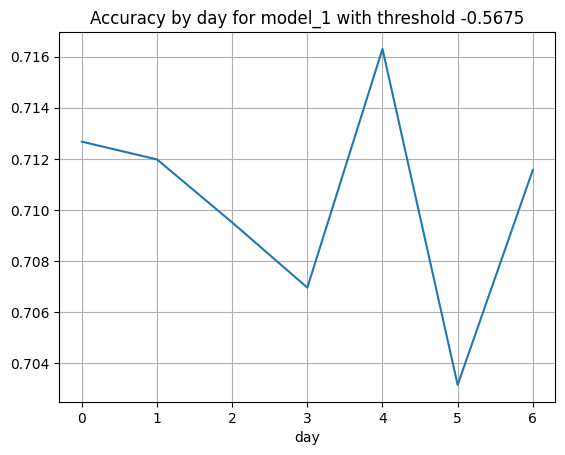

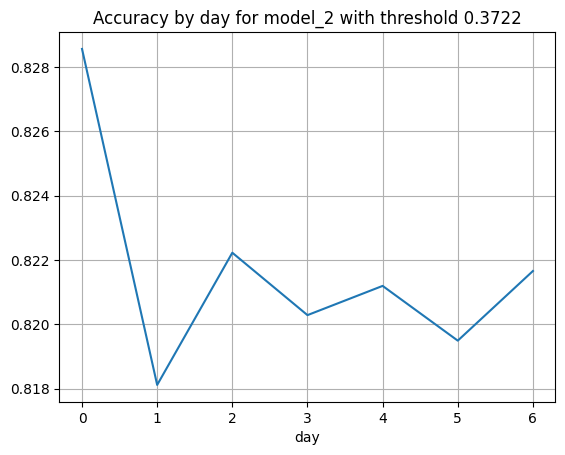

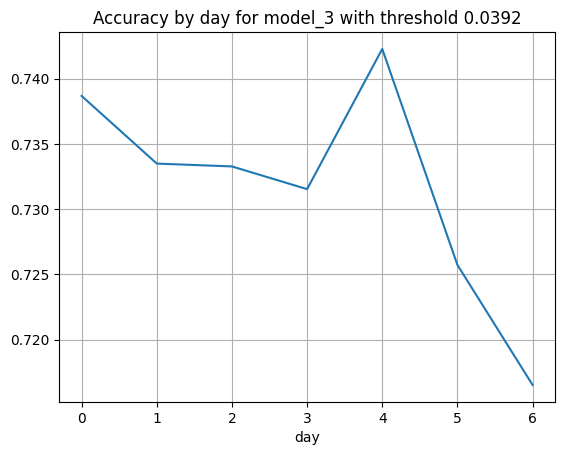

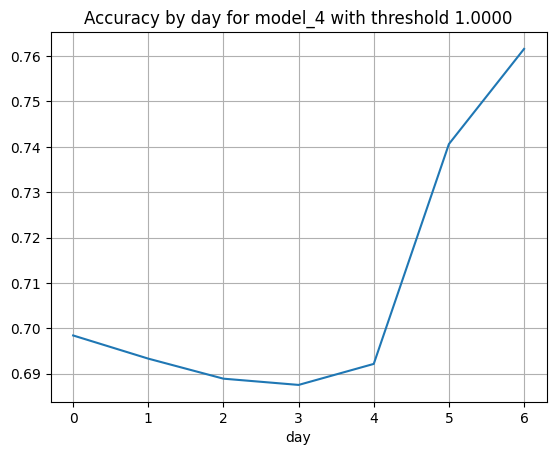

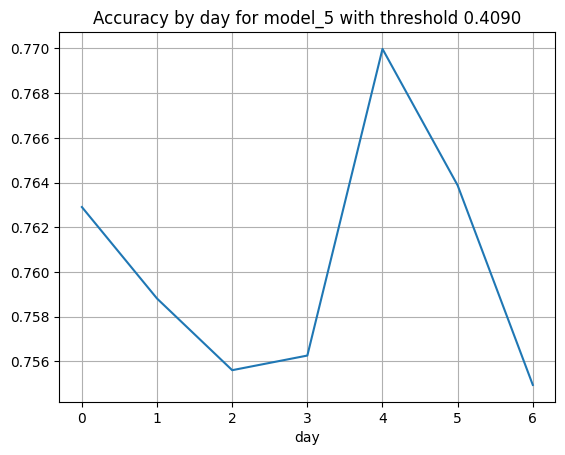

In [7]:
def get_best_threshold(labels: np.ndarray, preds: np.ndarray) -> float:
    fpr, tpr, thresholds = roc_curve(labels, preds)
    optimal_idx = np.argmax(tpr - fpr)
    return thresholds[optimal_idx]

thresholds = {model: get_best_threshold(df_val["target"], df_val[model]) for model in models}

for model, threshold in thresholds.items():
    model_preds = df_train[model].values >= threshold
    correct_preds = (model_preds.astype(np.int32) == df_train["target"].values).astype(np.int32)
    acc_by_day = pd.DataFrame({
        "day": df_train["order_create_day"].values,
        "accuracy": correct_preds
    })
    
    plt.figure()
    acc_by_day.groupby("day")["accuracy"].mean().plot()
    plt.title(f"Accuracy by day for {model} with threshold {threshold:.4f}")
    plt.grid()
    plt.show()
    plt.close()

In [8]:
scaler = ColumnTransformer(
    transformers=[
        ("scaler", MinMaxScaler(), models),
    ],
    remainder="passthrough",
)

df_train[models] = scaler.fit_transform(df_train[models])
df_val[models] = scaler.transform(df_val[models])
df_test[models] = scaler.transform(df_test[models])

In [9]:
agg_functions = {
    "min": np.min,
    "max": np.max,
    "mean": np.mean,
    "std": np.std,
    "prod": np.prod,
}

for name, func in agg_functions.items():
    feat = f"model_{name}"
    df_train[feat] = func(df_train[models], axis=1)
    df_val[feat] = func(df_val[models], axis=1)
    df_test[feat] = func(df_test[models], axis=1)

In [10]:
feats = df_train.columns.tolist()

for name in ["target", "order_create_time", "session_end_time"]:
    feats.remove(name)

x_train = df_train[feats]
x_val = df_val[feats]
x_test = df_test[feats]

y_train = df_train["target"]
y_val = df_val["target"]

In [11]:
model = lgb.LGBMClassifier(
    n_estimators=1000,
    random_state=SEED,
)

model.fit(
    x_train,
    y_train,
    eval_set=[(x_val[feats], y_val)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(period=10, show_stdv=False),
    ],
)

[LightGBM] [Info] Number of positive: 29679, number of negative: 53997
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001738 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2173
[LightGBM] [Info] Number of data points in the train set: 83676, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.354690 -> initscore=-0.598489
[LightGBM] [Info] Start training from score -0.598489
Training until validation scores don't improve for 100 rounds
[10]	valid_0's auc: 0.953701	valid_0's binary_logloss: 0.337244
[20]	valid_0's auc: 0.95463	valid_0's binary_logloss: 0.265091
[30]	valid_0's auc: 0.955072	valid_0's binary_logloss: 0.244038
[40]	valid_0's auc: 0.955515	valid_0's binary_logloss: 0.237954
[50]	valid_0's auc: 0.955492	valid_0's binary_logloss: 0.236399
[60]	valid_0's auc: 0.955541	valid_0's binary_logloss: 0.2359

LGBMClassifier(n_estimators=1000, random_state=1)

In [12]:
model_preds = x_val[models]
model_preds["model_final"] = model.predict_proba(x_val[feats])[:, 1]
model_preds["target"] = y_val

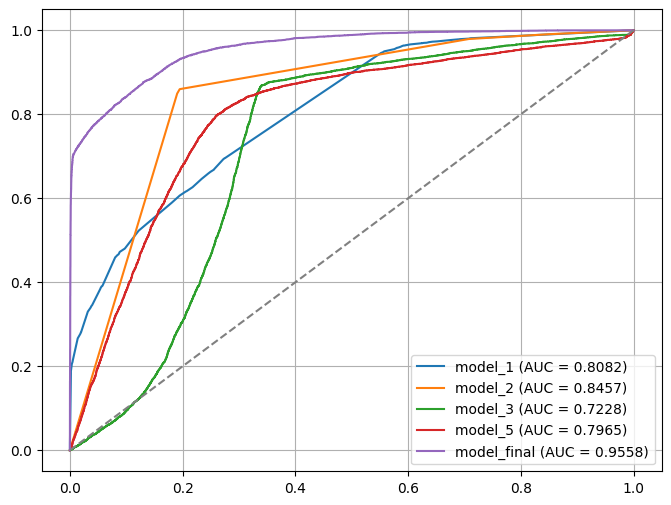

In [13]:
model_names = [f"model_{i}" for i in [1, 2, 3, 5, "final"]]

plt.figure(figsize=(8, 6))


for model_name in model_names:
    fpr, tpr, _ = roc_curve(model_preds["target"], model_preds[model_name])
    auc = roc_auc_score(model_preds["target"], model_preds[model_name])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.legend()
plt.grid()

plt.show()

In [14]:
y_pred = model.predict_proba(df_test[feats])[:, 1]
sample_submission["is_callcenter"] = y_pred

sample_submission.to_csv("submission.csv", index=False)